Ejercicio 2

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creamos un dataset simulando un registro de conexiones de red
data = {
    'timestamp': pd.date_range(start='2023-01-01', periods=10, freq='H'),
    'ip_origen': ['192.168.1.' + str(i) for i in range(1, 11)],
    'ip_destino': ['10.0.0.' + str(i % 3 + 1) for i in range(10)],
    'puerto': [80, 443, 22, 3389, 8080, 80, 443, 22, 8080, 3389],
    'protocolo': ['HTTP', 'HTTPS', 'SSH', 'RDP', 'HTTP', 'HTTP', 'HTTPS', 'SSH', 'HTTP', 'RDP'],
    'bytes_enviados': np.random.randint(100, 10000, 10),
    'exito_conexion': [True, True, False, True, True, True, False, False, True, True]
}

# Creamos el DataFrame
df = pd.DataFrame(data)

print("1. Explorando el DataFrame:")
print(df.head())
print("\nInformación del DataFrame:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

# 2. Selección de datos
print("\n2. Selección de datos:")
# Seleccionar una columna (devuelve una Serie)
print("\nSelección de una columna (Serie):")
print(df['protocolo'])

# Seleccionar múltiples columnas (devuelve un DataFrame)
print("\nSelección de múltiples columnas (DataFrame):")
print(df[['ip_origen', 'protocolo', 'puerto']])

# Selección por índice con iloc
print("\nSelección por índice con iloc (primeras 2 filas, columnas 0 y 2):")
print(df.iloc[0:2, [0, 2]])

# Selección por nombre con loc
print("\nSelección por nombre con loc (filas donde protocolo es 'HTTP'):")
print(df.loc[df['protocolo'] == 'HTTP', ['timestamp', 'ip_origen', 'puerto']])

# 3. Filtrado de datos
print("\n3. Filtrado de datos:")
# Filtrar conexiones exitosas
conexiones_exitosas = df[df['exito_conexion'] == True]
print("\nConexiones exitosas:")
print(conexiones_exitosas[['timestamp', 'ip_origen', 'protocolo']])

# Filtrado múltiple (conexiones HTTP en puerto 80)
http_port80 = df[(df['protocolo'] == 'HTTP') & (df['puerto'] == 80)]
print("\nConexiones HTTP en puerto 80:")
print(http_port80)

# 4. Transformación de datos
print("\n4. Transformación de datos:")
# Añadir una nueva columna
df['hora'] = df['timestamp'].dt.hour
print("\nDataFrame con nueva columna 'hora':")
print(df[['timestamp', 'hora', 'protocolo']])

# Aplicar una función con apply
def clasificar_protocolo(protocolo):
    if protocolo in ['HTTP', 'HTTPS']:
        return 'WEB'
    elif protocolo == 'SSH':
        return 'ADMIN'
    else:
        return 'OTRO'

df['tipo_servicio'] = df['protocolo'].apply(clasificar_protocolo)
print("\nDataFrame con clasificación de servicios:")
print(df[['protocolo', 'tipo_servicio']])

# 5. Agregación de datos
print("\n5. Agregación de datos:")
# Agrupar por protocolo y contar conexiones
conteo_por_protocolo = df.groupby('protocolo').size()
print("\nConteo de conexiones por protocolo:")
print(conteo_por_protocolo)

# Estadísticas por protocolo
stats_por_protocolo = df.groupby('protocolo')['bytes_enviados'].agg(['count', 'mean', 'min', 'max'])
print("\nEstadísticas de bytes enviados por protocolo:")
print(stats_por_protocolo)

# 6. Pivotado de datos
print("\n6. Pivotado de datos:")
# Tabla pivote de bytes enviados por tipo de servicio y protocolo
pivot = pd.pivot_table(df, 
                      values='bytes_enviados', 
                      index='tipo_servicio', 
                      columns='exito_conexion', 
                      aggfunc='mean')
print("\nTabla pivote de bytes enviados por tipo de servicio y éxito de conexión:")
print(pivot)

# 7. Detección de anomalías simples
print("\n7. Detección de anomalías simples:")
# Calcular el Z-score para identificar valores atípicos en bytes_enviados
df['z_score'] = (df['bytes_enviados'] - df['bytes_enviados'].mean()) / df['bytes_enviados'].std()
anomalias = df[abs(df['z_score']) > 1.5]  # Consideramos como anómalos Z-scores > 1.5
print("\nPosibles conexiones anómalas por volumen de datos transferidos:")
print(anomalias[['timestamp', 'ip_origen', 'protocolo', 'bytes_enviados', 'z_score']])

1. Explorando el DataFrame:
            timestamp    ip_origen ip_destino  puerto protocolo  \
0 2023-01-01 00:00:00  192.168.1.1   10.0.0.1      80      HTTP   
1 2023-01-01 01:00:00  192.168.1.2   10.0.0.2     443     HTTPS   
2 2023-01-01 02:00:00  192.168.1.3   10.0.0.3      22       SSH   
3 2023-01-01 03:00:00  192.168.1.4   10.0.0.1    3389       RDP   
4 2023-01-01 04:00:00  192.168.1.5   10.0.0.2    8080      HTTP   

   bytes_enviados  exito_conexion  
0            6873            True  
1            3916            True  
2             817           False  
3            4534            True  
4             758            True  

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       10 non-null     datetime64[ns]
 1   ip_origen       10 non-null     object        
 2   ip_destino 

/tmp/ipykernel_66823/1374602138.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'timestamp': pd.date_range(start='2023-01-01', periods=10, freq='H'),


1. Explorando el DataFrame:
  fecha_descarga usuario       genero  cantidad_descargas  exito_descarga
0     2019-01-31  user_1      Hip-Hop                 255            True
1     2019-02-28  user_2  Electrónica                 325            True
2     2019-03-31  user_3         Rock                 190            True
3     2019-04-30  user_4         Rock                 308            True
4     2019-05-31  user_5  Electrónica                 345            True

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha_descarga      100 non-null    datetime64[ns]
 1   usuario             100 non-null    object        
 2   genero              100 non-null    object        
 3   cantidad_descargas  100 non-null    int64         
 4   exito_descarga      100 non-null    bool          
dtype

/tmp/ipykernel_66823/2672047131.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'fecha_descarga': pd.date_range(start='2019-01-01', periods=100, freq='M'),


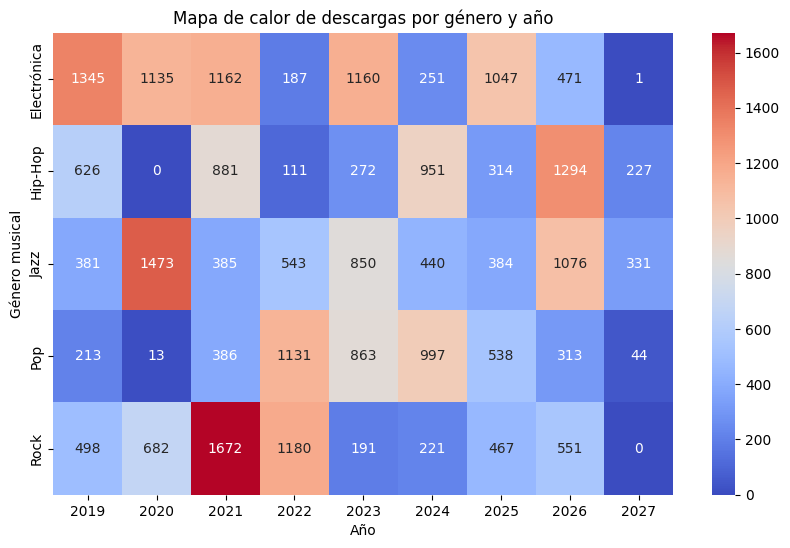

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creamos un dataset simulando un registro de descargas de canciones en los últimos 5 años
data = {
    'fecha_descarga': pd.date_range(start='2019-01-01', periods=100, freq='M'),
    'usuario': ['user_' + str(i) for i in range(1, 101)],
    'genero': np.random.choice(['Pop', 'Rock', 'Hip-Hop', 'Electrónica', 'Jazz'], 100),
    'cantidad_descargas': np.random.randint(1, 500, 100),
    'exito_descarga': np.random.choice([True, False], 100, p=[0.9, 0.1])
}

# Creamos el DataFrame
df = pd.DataFrame(data)

print("1. Explorando el DataFrame:")
print(df.head())
print("\nInformación del DataFrame:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

# 2. Selección de datos
print("\n2. Selección de datos:")
print("\nSelección de una columna (Serie):")
print(df['genero'])

print("\nSelección de múltiples columnas (DataFrame):")
print(df[['usuario', 'genero', 'cantidad_descargas']])

print("\nSelección por índice con iloc (primeras 2 filas, columnas 0 y 2):")
print(df.iloc[0:2, [0, 2]])

print("\nSelección por nombre con loc (filas donde el género es 'Rock'):")
print(df.loc[df['genero'] == 'Rock', ['fecha_descarga', 'usuario', 'cantidad_descargas']])

# 3. Filtrado de datos
print("\n3. Filtrado de datos:")
descargas_exitosas = df[df['exito_descarga'] == True]
print("\nDescargas exitosas:")
print(descargas_exitosas[['fecha_descarga', 'usuario', 'genero']])

# Filtrado múltiple (descargas de Pop mayores a 200)
pop_mas_200 = df[(df['genero'] == 'Pop') & (df['cantidad_descargas'] > 200)]
print("\nDescargas de Pop con más de 200 descargas:")
print(pop_mas_200)

# 4. Transformación de datos
df['año'] = df['fecha_descarga'].dt.year
print("\nDataFrame con nueva columna 'año':")
print(df[['fecha_descarga', 'año', 'genero']])

def clasificar_genero(genero):
    if genero in ['Pop', 'Rock']:
        return 'Popular'
    elif genero in ['Hip-Hop', 'Electrónica']:
        return 'Urbano'
    else:
        return 'Clásico'

df['categoria'] = df['genero'].apply(clasificar_genero)
print("\nDataFrame con clasificación de géneros:")
print(df[['genero', 'categoria']])

# 5. Agregación de datos
conteo_por_genero = df.groupby('genero').size()
print("\nConteo de descargas por género:")
print(conteo_por_genero)

stats_por_genero = df.groupby('genero')['cantidad_descargas'].agg(['count', 'mean', 'min', 'max'])
print("\nEstadísticas de descargas por género:")
print(stats_por_genero)

# 6. Pivotado de datos
pivot = pd.pivot_table(df, values='cantidad_descargas', index='categoria', columns='exito_descarga', aggfunc='mean')
print("\nTabla pivote de descargas por categoría y éxito de descarga:")
print(pivot)

# 7. Detección de anomalías simples
df['z_score'] = (df['cantidad_descargas'] - df['cantidad_descargas'].mean()) / df['cantidad_descargas'].std()
anomalias = df[abs(df['z_score']) > 1.5]
print("\nPosibles descargas anómalas por volumen de descargas:")
print(anomalias[['fecha_descarga', 'usuario', 'genero', 'cantidad_descargas', 'z_score']])

# 8. Visualización con mapa de calor
plt.figure(figsize=(10, 6))
sns.heatmap(df.pivot_table(index='genero', columns='año', values='cantidad_descargas', aggfunc='sum').fillna(0), cmap='coolwarm', annot=True, fmt='.0f')
plt.title("Mapa de calor de descargas por género y año")
plt.xlabel("Año")
plt.ylabel("Género musical")
plt.show()

